# ЛАБОРАТОРНА РОБОТА №4
## Геометричні перетворення координат у просторі

In [358]:
import numpy as np
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

### Задати куб через його вершини. Здійснити масштабування куба (збільшення, зменшення у кілька разів).

In [359]:
def plot_cube(points, color1, color2, lim):
 
    faces = [
        [points[0], points[1], points[2], points[3]],
        [points[4], points[5], points[6], points[7]],
        [points[0], points[1], points[5], points[4]],
        [points[2], points[3], points[7], points[6]],
        [points[1], points[2], points[6], points[5]],
        [points[4], points[7], points[3], points[0]]
    ]

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.add_collection3d(Poly3DCollection(faces, facecolors=color1, linewidths=1, edgecolors=color2, alpha=0.5))
    ax.scatter(0, 0, 0, color='k', s = 30)
    
    ax.view_init(elev=20, azim=30)

    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_zlim(0, lim)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

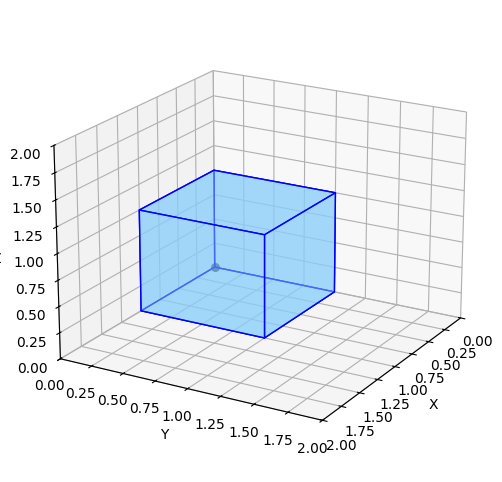

In [360]:
points = np.array([
    [0, 0, 0], [1, 0, 0], [1, 1, 0], [0, 1, 0],
    [0, 0, 1], [1, 0, 1], [1, 1, 1], [0, 1, 1]
])

plot_cube(points,'LightSkyBlue', 'b', 2)

In [361]:
def scale(points, scale):
    
    transformed_points = np.vstack((points.T, np.ones(points.shape[0])))
    centr = (np.mean(points, axis=0))
  
    s = 1/scale
    
    m1 = np.array([[1, 0, 0, -1*centr[0]],
                  [0, 1, 0, -1*centr[1]],
                  [0, 0, 1, -1*centr[2]],
                  [0, 0 , 0, 1]])
    
    m2 = np.array([[s, 0, 0, 0],
                  [0, s, 0, 0],
                  [0, 0 , s, 0],
                   [0, 0 , 0, 1]])
    
    m3 = np.array([[1, 0, 0, 1*centr[0]],
                  [0, 1, 0, 1*centr[1]],
                  [0, 0, 1, 1*centr[2]],
                  [0, 0 , 0, 1]])
    
    new_points = (m3@ (m2 @ (m1 @ transformed_points)))
    
    return new_points[:3].T

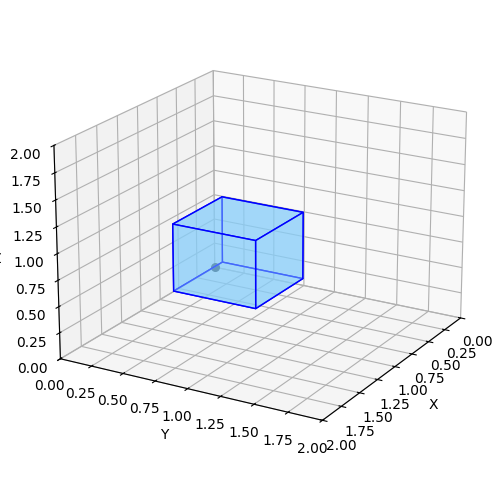

In [362]:
scaled_points = scale(points, 1.5)
plot_cube(scaled_points,'LightSkyBlue', 'b', 2)

### Отриманий результат з попереднього пункту симетрично відобразити відносно початку координат, відносно однієї з координатних площин у тривимірній декартовій системі координат

In [363]:
def symetric_original(points):
   
    points_t = np.vstack((points.T, np.ones(points.shape[0])))
        # Симетрія відносно XY площини: змінюємо Z
    m = np.array([[-1, 0, 0, 0],
                  [0, -1, 0, 0],
                  [0, 0, -1, 0],
                  [0, 0, 0, 1]])
    
    new_points = m @ points_t
    
    return new_points[:3].T 

Text(0.5, 0.92, 'Відображення куба відносно початку координат')

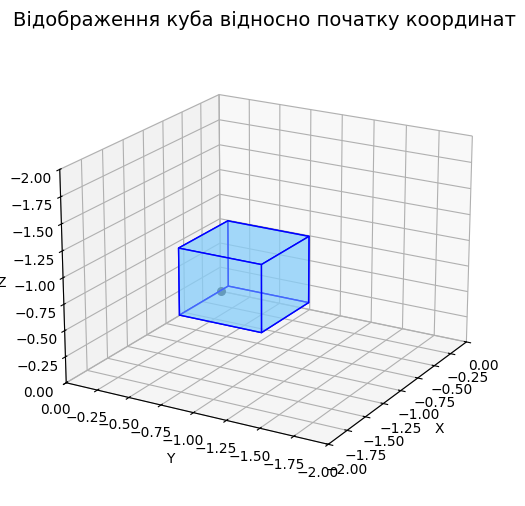

In [364]:
symmetric_original = symetric_original(scaled_points)
plot_cube(symmetric_original,'LightSkyBlue', 'b', -2)
plt.title("Відображення куба відносно початку координат", fontsize=14)

In [365]:
def symetric_plane(points):
   
    points_t = np.vstack((points.T, np.ones(points.shape[0])))
        # Симетрія відносно XZ площини
    m = np.array([[1, 0, 0, 0],
                  [0, -1, 0, 0],
                  [0, 0, 1, 0],
                  [0, 0, 0, 1]])
    
    new_points = m @ points_t
    
    return new_points[:3].T 

Text(0.5, 0.92, 'Відображення куба відносно XZ площини')

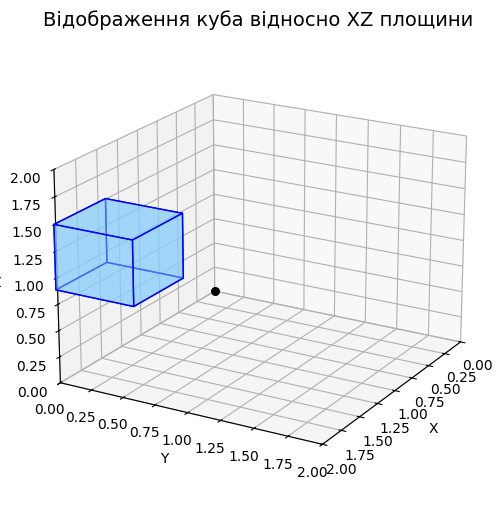

In [366]:
symetric_plane = symetric_plane(scaled_points)
plot_cube(symetric_plane,'LightSkyBlue', 'b', 2)
plt.title("Відображення куба відносно XZ площини", fontsize=14)

### Задати пряму, здійснити поворот куба відносно прямої на деякий кут φ. Вказати перетворення, які необхідні для одержання такого результату.

In [367]:
def symetric_line(points, x0, y0, z0, v, fi):
    
    points_t = np.vstack((points.T, np.ones(points.shape[0])))

    l, m, n = v
    
    # Будуємо матрицю переміщення на вектор (−x0; −y0; −z0). У результаті цього переміщення ми отримуємо те, що пряма L проходить 
    # через початок координат.
    m1 = np.array([[1, 0, 0, -x0],
                  [0, 1, 0, -y0],
                  [0, 0, 1, -z0],
                  [0, 0, 0, 1]])
    
    # Перший поворот – поворот навколо осі абсцис на кут −ψ.
    module_mn = math.sqrt(n**2 + m**2)
    cos_psi = n / module_mn
    sin_psi = m / module_mn
    
    Rx = np.array([[1, 0, 0, 0],
                  [0, cos_psi, -sin_psi, 0],
                  [0, sin_psi, cos_psi, 0],
                  [0, 0, 0, 1]])
    
    # Застосувавши перетворення, що описує ця матриця до вектора (l; m; n), отримаємо направляючий вектор прямої L в новій системі координат:
    v_ = np.append(v, 1)
    new_v = v_ @ Rx 
    
    # Другий поворот – поворот навколо осі ординат на кут θ.
    cos_teta = new_v[2]
    sin_teta = new_v[0]
    
    Ry = np.array([[cos_teta, 0, -sin_teta, 0],
                  [0, 1, 0, 0],
                  [sin_teta, 0, cos_teta, 0],
                  [0, 0, 0, 1]])
    
    # Поворот навколо прямої L на заданий кут φ. Оскільки тепер пряма L співпадає з віссю аплікат
    Rz = np.array([[np.cos(fi), -np.sin(fi), 0, 0],
                  [np.sin(fi), np.cos(fi), 0, 0],
                  [0, 0, 1, 0],
                  [0, 0, 0, 1]])
    
    # Виконуємо поворот навколо осі ординат на кут −θ:
    Ry_= np.array([[cos_teta, 0, sin_teta, 0],
                  [0, 1, 0, 0],
                  [-sin_teta, 0, cos_teta, 0],
                  [0, 0, 0, 1]])
   
   # Потім виконуємо поворот навколо осі абсцис на кут −ψ: 
    Rx_ = np.array([[1, 0, 0, 0],
                  [0, cos_psi, sin_psi, 0],
                  [0, -sin_psi, cos_psi, 0],
                  [0, 0, 0, 1]])
    
    # І останнім робимо переміщення на вектор (x0; y0; z0)
    m1_ = np.array([[1, 0, 0, x0],
                  [0, 1, 0, y0],
                  [0, 0, 1, z0],
                  [0, 0, 0, 1]])
    
    new_points = (m1_  @ (Rx_  @ (Ry_  @ (Rz @ (Ry @ (Rx @ (m1 @ points_t)))))))
    
    return new_points[:3].T

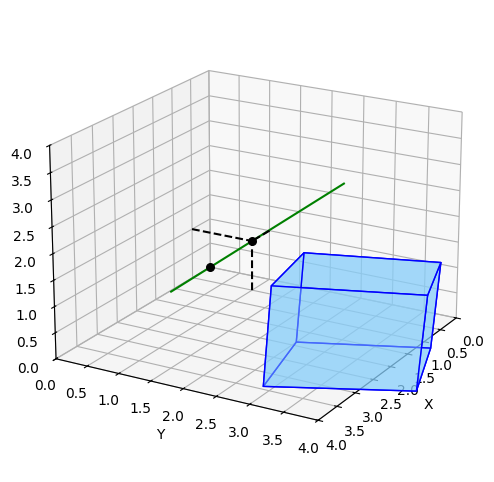

In [ ]:
x0, y0, z0 = 0.5, 1, 1
v = np.array([2.5, 1, 2])
t = np.linspace(-2, 2, 100)  

x = x0 + t * x0
y = y0 + t * y0
z = z0 + t * z0

symetric_line = symetric_line(scaled_points, x0, y0, z0, v, np.pi/2)
plot_cube(symetric_line,'LightSkyBlue', 'b', 4)

ax = plt.gca()
ax.plot(x, y, z, color="green")
ax.scatter(x0, y0, z0, color="k", s=30)

ax.plot([x0, x0], [y0, y0], [0, z0], 'k--') 
ax.plot([x0, x0], [0, y0], [z0, z0], 'k--')  
ax.plot([0, x0], [y0, y0], [z0, z0], 'k--') 

plt.show()

### Задати площину, здійснити симетрію куба відносно площини, вказати всі математичні перетворення. Записати відповідні математичні перетворення.
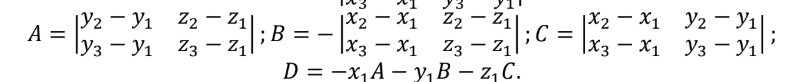
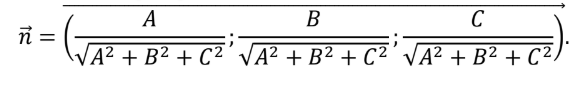

In [369]:
x1, y1, z1 = 1, 2, 1
x2, y2, z2 = 2, 3, 1
x3, y3, z3 = 4, 1, 2

a = (y2 - y1) * (z3 - z1) - (y3 - y1) * (z2 - z1)
b = (z2 - z1) * (x3 - x1) - (z3 - z1) * (x2 - x1)
c = (x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1)
d = -a * x1 - b * y1 - c * z1

module = math.sqrt(a**2 + b**2 + c**2)
normal_vector = np.array([a, b, c]) / module

print(f"Рівняння площини: {a}x + {b}y + {c}z + {d} = 0")
print(f"Нормований вектор нормалі: {normal_vector}")

Рівняння площини: 1x + -1y + -4z + 5 = 0
Нормований вектор нормалі: [ 0.23570226 -0.23570226 -0.94280904]


In [370]:
def symetric_plane(points, a, b, c, d):
    
    points_t = np.vstack((points.T, np.ones(points.shape[0])))
    
    #Зсув площини так, щоб вона проходила через початок координат
    m1 = np.array([[1, 0, 0, 0],
                  [0, 1, 0, 0],
                  [0, 0, 1, d/c],
                  [0, 0, 0, 1]])
    
    # Далі здійснюєм оперший поворот до осі абсцис на кут −φ
    module_ab = math.sqrt(a**2 + b**2)
    cos_fi = a/ module_ab
    sin_fi = b /module_ab
    
    m2 = np.array([[cos_fi, sin_fi, 0, 0],
                  [-sin_fi, cos_fi, 0, 0],
                  [0, 0, 1, 0],
                  [0, 0, 0, 1]])

    # Здійснюєио поворот відносно осі OY на кут ψ
    module_abc = math.sqrt(a**2 + b**2+ c**2)
    cos_psi = c/ module_abc
    sin_psi = module_ab / module_abc
    
    m3 = np.array([[cos_psi, 0, -sin_psi, 0],
                  [0, 1, 0, 0],
                  [sin_psi, 0, cos_psi, 0],
                  [0, 0, 0, 1]])
    
    # Тепер ми знаходимось у площині z = 0.
    # Далі робимо симетрію відносно площини z = 0:
    m4 = np.array([[1, 0, 0, 0],
                  [0, 1, 0, 0],
                  [0, 0, -1, 0],
                  [0, 0, 0, 1]])
    
    # Здійснюємо поворот на кут −ψ відносно осі OY:
    m5 = np.array([[cos_psi, 0, sin_psi, 0],
                  [0, 1, 0, 0],
                  [-sin_psi, 0, cos_psi, 0],
                  [0, 0, 0, 1]])
    
    # Здійснюємо поворот на кут φ відносно осі OZ:
    m6 = np.array([[cos_fi, -sin_fi, 0, 0],
                  [sin_fi, cos_fi, 0, 0],
                  [0, 0, 1, 0],
                  [0, 0, 0, 1]])
    
    # Зсув площини так, на вектор (0; 0;D).
    m7 = np.array([[1, 0, 0, 0],
                  [0, 1, 0, 0],
                  [0, 0, 1, -d/c],
                  [0, 0, 0, 1]])
    
    new_points = (m7  @ (m6  @ (m5  @ (m4 @ (m3 @ (m2 @ (m1 @ points_t)))))))
    
    return new_points[:3].T

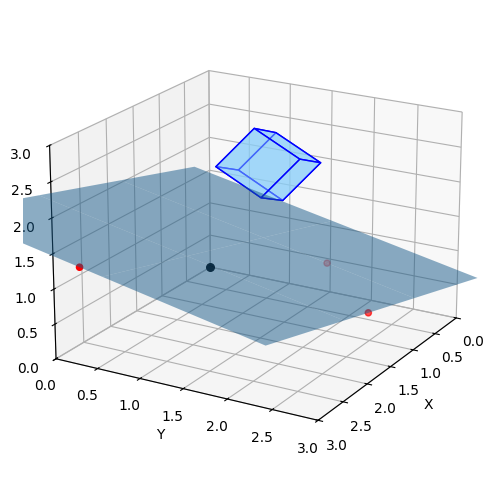

In [371]:
symetric_plane = symetric_plane(scaled_points, a, b, c, d)
plot_cube(symetric_plane,'LightSkyBlue', 'b', 3)

ax = plt.gca()
xx, yy = np.meshgrid(np.linspace(-0.5, 4, 4), np.linspace(-0.5, 3, 3))
zz = (-a * xx - b * yy - d) / c
ax.plot_surface(xx, yy, zz, alpha = 0.5)

ax.scatter([x1, x2, x3], [y1, y2, y3], [z1, z2, z3], color='red')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()

### Здійснити ортогональне проектування даного кубу на площину загального виду, яка не паралельна жодній з координатних площин. Вказати відповідні математичні перетворення.

In [372]:
print(f"Рівняння площини: {a}x + {b}y + {c}z + {d} = 0")

Рівняння площини: 1x + -1y + -4z + 5 = 0


In [ ]:
def orthogonal_project(points, a, b, c, d):

    vector = np.array([a, b, c])
    scalar = a**2 + b**2 + c**2
    
    project_points = []

    for point in points:
        x, y, z = point
        p = np.array([x, y, z])
        distance = (a * x + b * y + c * z + d) / scalar
        new_p = p - distance * vector
        project_points.append(new_p)

    return np.array(project_points)

orthogonal_points = orthogonal_project(scaled_points, a, b, c, d)

Text(0.5, 0, 'Z')

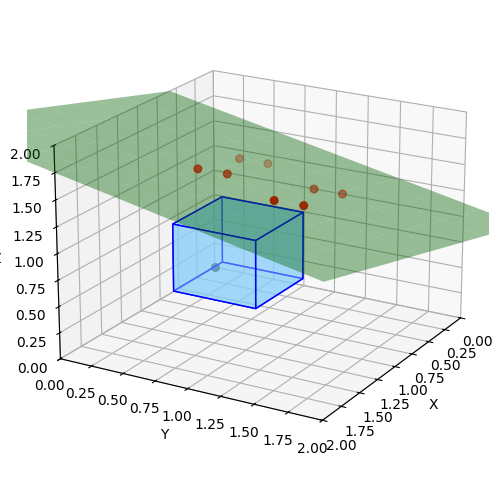

In [374]:
plot_cube(scaled_points,'LightSkyBlue', 'b', 2)
ax = plt.gca()
ax.scatter(orthogonal_points[:, 0], orthogonal_points[:, 1], orthogonal_points[:, 2], c='red', label='Проєктовані точки', s=30)

xx, yy = np.meshgrid(np.linspace(-1, 2, 10), np.linspace(-1, 2, 10))
zz = (-d - a * xx - b * yy) / c
ax.plot_surface(xx, yy, zz, alpha=0.4, color='green', label='Площина')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')